In [ ]:
import pandas as pd

earn = pd.read_csv("/content/tesla_earnings_sentiment.csv")

print(earn.columns)
earn.head()

Index(['ticker', 'year', 'quarter', 'source_file', 'finbert_sentiment'], dtype='object')


,ticker,year,quarter,source_file,finbert_sentiment
0,TSLA,2015,2,Tesla_Q2_2015_Shareholder_Letter.txt,0.530286
1,TSLA,2015,3,Q3_15_Shareholder_Letter.txt,0.383116
2,TSLA,2015,4,Q4_15_Tesla_Update_Letter.txt,0.402265
3,TSLA,2016,1,Q1_2016_Tesla_Shareholder_Letter.txt,0.456255
4,TSLA,2016,2,Q2_16_Update_Letter_-_final.txt,0.648278


In [ ]:
# map quarter → approximate earnings date
quarter_month_day = {
    1: (4, 20),
    2: (7, 20),
    3: (10, 20),
    4: (1, 20)
}

def get_date(row):
    y = int(row["year"])
    q = int(row["quarter"])
    m, d = quarter_month_day[q]
    if q == 4:
        y += 1
    return pd.Timestamp(y, m, d)

earn["date"] = earn.apply(get_date, axis=1)

# keep only needed columns
earn = earn[["date", "finbert_sentiment"]].rename(
    columns={"finbert_sentiment": "earnings_sentiment_current"}
)

earn = earn.sort_values("date").reset_index(drop=True)

earn.head()

,date,earnings_sentiment_current
0,2015-07-20,0.530286
1,2015-10-20,0.383116
2,2016-01-20,0.402265
3,2016-04-20,0.456255
4,2016-07-20,0.648278


In [ ]:
earn_2022 = earn[
    (earn["date"] >= "2022-01-01") &
    (earn["date"] < "2023-01-01")
].copy()

earn_2022

,date,earnings_sentiment_current
12,2022-01-20,0.197037
13,2022-04-20,0.064095
14,2022-07-20,0.518666


In [ ]:
import yfinance as yf
import pandas as pd

# Download ONLY 2022 Tesla data
tsla = yf.download(
    "TSLA",
    start="2022-01-01",
    end="2023-01-01",
    auto_adjust=True,
    progress=False
)

# Reset index
tsla = tsla.reset_index()

# Rename columns
tsla = tsla.rename(columns={
    "Date": "date",
    "Close": "close",
    "Open": "open",
    "High": "high",
    "Low": "low",
    "Volume": "volume"
})

# Sort
tsla = tsla.sort_values("date").reset_index(drop=True)

# Create features
tsla["return_1d"] = tsla["close"].pct_change()
tsla["prev_return"] = tsla["return_1d"].shift(1)
tsla["volatility_5"] = tsla["return_1d"].rolling(5).std()

# Target (next day return)
tsla["target_next_day_return"] = tsla["return_1d"].shift(-1)

tsla.head()

Price,date,close,high,low,open,volume,return_1d,prev_return,volatility_5,target_next_day_return
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA,,,,
0,2022-01-03,399.926666,400.356659,378.679993,382.583344,103931400,NaN,NaN,NaN,-0.041833
1,2022-01-04,383.196655,402.666656,374.350006,396.516663,100248300,-0.041833,NaN,NaN,-0.053471
2,2022-01-05,362.706665,390.113342,360.336670,382.216675,80119800,-0.053471,-0.041833,NaN,-0.021523
3,2022-01-06,354.899994,362.666656,340.166656,359.000000,90336600,-0.021523,-0.053471,NaN,-0.035447
4,2022-01-07,342.320007,360.309998,336.666656,360.123322,84164700,-0.035447,-0.021523,NaN,0.030342


In [ ]:
print(tsla.columns)

MultiIndex([(                  'date',     ''),
            (                 'close', 'TSLA'),
            (                  'high', 'TSLA'),
            (                   'low', 'TSLA'),
            (                  'open', 'TSLA'),
            (                'volume', 'TSLA'),
            (             'return_1d',     ''),
            (           'prev_return',     ''),
            (          'volatility_5',     ''),
            ('target_next_day_return',     '')],
           names=['Price', 'Ticker'])


In [ ]:
# Flatten MultiIndex columns if they exist
if isinstance(tsla.columns, pd.MultiIndex):
    tsla.columns = [col[0] if col[1] == "" else col[0] for col in tsla.columns]

print(tsla.columns)
tsla.head()

Index(['date', 'close', 'high', 'low', 'open', 'volume', 'return_1d',
       'prev_return', 'volatility_5', 'target_next_day_return'],
      dtype='object')


,date,close,high,low,open,volume,return_1d,prev_return,volatility_5,target_next_day_return
0,2022-01-03,399.926666,400.356659,378.679993,382.583344,103931400,NaN,NaN,NaN,-0.041833
1,2022-01-04,383.196655,402.666656,374.350006,396.516663,100248300,-0.041833,NaN,NaN,-0.053471
2,2022-01-05,362.706665,390.113342,360.336670,382.216675,80119800,-0.053471,-0.041833,NaN,-0.021523
3,2022-01-06,354.899994,362.666656,340.166656,359.000000,90336600,-0.021523,-0.053471,NaN,-0.035447
4,2022-01-07,342.320007,360.309998,336.666656,360.123322,84164700,-0.035447,-0.021523,NaN,0.030342


In [ ]:
# Keep only needed columns
tsla = tsla[["date", "open", "high", "low", "close", "volume", "return_1d", "prev_return", "volatility_5", "target_next_day_return"]].copy()

tsla["date"] = pd.to_datetime(tsla["date"])
tsla = tsla.sort_values("date").reset_index(drop=True)

tsla.head()

,date,open,high,low,close,volume,return_1d,prev_return,volatility_5,target_next_day_return
0,2022-01-03,382.583344,400.356659,378.679993,399.926666,103931400,NaN,NaN,NaN,-0.041833
1,2022-01-04,396.516663,402.666656,374.350006,383.196655,100248300,-0.041833,NaN,NaN,-0.053471
2,2022-01-05,382.216675,390.113342,360.336670,362.706665,80119800,-0.053471,-0.041833,NaN,-0.021523
3,2022-01-06,359.000000,362.666656,340.166656,354.899994,90336600,-0.021523,-0.053471,NaN,-0.035447
4,2022-01-07,360.123322,360.309998,336.666656,342.320007,84164700,-0.035447,-0.021523,NaN,0.030342


In [ ]:
earn_2022["date"] = pd.to_datetime(earn_2022["date"])
earn_2022 = earn_2022.sort_values("date").reset_index(drop=True)

tsla_earn = pd.merge_asof(
    tsla,
    earn_2022,
    on="date",
    direction="backward"
)

tsla_earn["earnings_sentiment_current"] = tsla_earn["earnings_sentiment_current"].fillna(0)

tsla_earn.head(15)

,date,open,high,low,close,volume,return_1d,prev_return,volatility_5,target_next_day_return,earnings_sentiment_current
0,2022-01-03,382.583344,400.356659,378.679993,399.926666,103931400,NaN,NaN,NaN,-0.041833,0.000000
1,2022-01-04,396.516663,402.666656,374.350006,383.196655,100248300,-0.041833,NaN,NaN,-0.053471,0.000000
2,2022-01-05,382.216675,390.113342,360.336670,362.706665,80119800,-0.053471,-0.041833,NaN,-0.021523,0.000000
3,2022-01-06,359.000000,362.666656,340.166656,354.899994,90336600,-0.021523,-0.053471,NaN,-0.035447,0.000000
4,2022-01-07,360.123322,360.309998,336.666656,342.320007,84164700,-0.035447,-0.021523,NaN,0.030342,0.000000
5,2022-01-10,333.333344,353.033325,326.666656,352.706665,91815000,0.030342,-0.035447,0.032696,0.005935,0.000000
6,2022-01-11,351.223328,358.616669,346.273346,354.799988,66063300,0.005935,0.030342,0.033297,0.039290,0.000000
7,2022-01-12,359.616669,371.613342,357.529999,368.739990,83739000,0.039290,0.005935,0.032211,-0.067491,0.000000
8,2022-01-13,369.690002,371.866669,342.179993,343.853333,97209900,-0.067491,0.039290,0.045170,0.017498,0.000000
9,2022-01-14,339.959991,350.666656,337.793335,349.869995,72924300,0.017498,-0.067491,0.042515,-0.018197,0.000000


In [ ]:
import pandas as pd

# fix tsla columns if multiindex
if isinstance(tsla.columns, pd.MultiIndex):
    tsla.columns = [col[0] if col[1] == "" else col[0] for col in tsla.columns]

# keep required columns
tsla = tsla[["date", "open", "high", "low", "close", "volume", "return_1d", "prev_return", "volatility_5", "target_next_day_return"]].copy()
tsla["date"] = pd.to_datetime(tsla["date"])
tsla = tsla.sort_values("date").reset_index(drop=True)

earn_2022["date"] = pd.to_datetime(earn_2022["date"])
earn_2022 = earn_2022.sort_values("date").reset_index(drop=True)

tsla_earn = pd.merge_asof(
    tsla,
    earn_2022,
    on="date",
    direction="backward"
)

tsla_earn["earnings_sentiment_current"] = tsla_earn["earnings_sentiment_current"].fillna(0)

tsla_earn.head(15)

,date,open,high,low,close,volume,return_1d,prev_return,volatility_5,target_next_day_return,earnings_sentiment_current
0,2022-01-03,382.583344,400.356659,378.679993,399.926666,103931400,NaN,NaN,NaN,-0.041833,0.000000
1,2022-01-04,396.516663,402.666656,374.350006,383.196655,100248300,-0.041833,NaN,NaN,-0.053471,0.000000
2,2022-01-05,382.216675,390.113342,360.336670,362.706665,80119800,-0.053471,-0.041833,NaN,-0.021523,0.000000
3,2022-01-06,359.000000,362.666656,340.166656,354.899994,90336600,-0.021523,-0.053471,NaN,-0.035447,0.000000
4,2022-01-07,360.123322,360.309998,336.666656,342.320007,84164700,-0.035447,-0.021523,NaN,0.030342,0.000000
5,2022-01-10,333.333344,353.033325,326.666656,352.706665,91815000,0.030342,-0.035447,0.032696,0.005935,0.000000
6,2022-01-11,351.223328,358.616669,346.273346,354.799988,66063300,0.005935,0.030342,0.033297,0.039290,0.000000
7,2022-01-12,359.616669,371.613342,357.529999,368.739990,83739000,0.039290,0.005935,0.032211,-0.067491,0.000000
8,2022-01-13,369.690002,371.866669,342.179993,343.853333,97209900,-0.067491,0.039290,0.045170,0.017498,0.000000
9,2022-01-14,339.959991,350.666656,337.793335,349.869995,72924300,0.017498,-0.067491,0.042515,-0.018197,0.000000


Merge News Sentiment

In [ ]:
# Load your news file
news = pd.read_csv("/content/Tesla_sentiment_2022.csv")

# Fix types
news["date"] = pd.to_datetime(news["date"])
news = news.sort_values("date").reset_index(drop=True)

# Rename for consistency
news = news.rename(columns={"daily_sentiment": "news_sentiment_daily"})

news.head()

,date,news_sentiment_daily
0,2022-01-03,-0.88
1,2022-01-08,0.00
2,2022-01-13,-0.94
3,2022-01-14,-0.83
4,2022-01-15,-0.94


Now merge it into  dataset

In [ ]:
# Merge with your current dataset (tsla_earn)
tsla_full = tsla_earn.merge(
    news,
    on="date",
    how="left"
)

# Fill missing days (no news → neutral)
tsla_full["news_sentiment_daily"] = tsla_full["news_sentiment_daily"].fillna(0)

tsla_full.head(15)

,date,open,high,low,close,volume,return_1d,prev_return,volatility_5,target_next_day_return,earnings_sentiment_current,news_sentiment_daily
0,2022-01-03,382.583344,400.356659,378.679993,399.926666,103931400,NaN,NaN,NaN,-0.041833,0.000000,-0.88
1,2022-01-04,396.516663,402.666656,374.350006,383.196655,100248300,-0.041833,NaN,NaN,-0.053471,0.000000,0.00
2,2022-01-05,382.216675,390.113342,360.336670,362.706665,80119800,-0.053471,-0.041833,NaN,-0.021523,0.000000,0.00
3,2022-01-06,359.000000,362.666656,340.166656,354.899994,90336600,-0.021523,-0.053471,NaN,-0.035447,0.000000,0.00
4,2022-01-07,360.123322,360.309998,336.666656,342.320007,84164700,-0.035447,-0.021523,NaN,0.030342,0.000000,0.00
5,2022-01-10,333.333344,353.033325,326.666656,352.706665,91815000,0.030342,-0.035447,0.032696,0.005935,0.000000,0.00
6,2022-01-11,351.223328,358.616669,346.273346,354.799988,66063300,0.005935,0.030342,0.033297,0.039290,0.000000,0.00
7,2022-01-12,359.616669,371.613342,357.529999,368.739990,83739000,0.039290,0.005935,0.032211,-0.067491,0.000000,0.00
8,2022-01-13,369.690002,371.866669,342.179993,343.853333,97209900,-0.067491,0.039290,0.045170,0.017498,0.000000,-0.94
9,2022-01-14,339.959991,350.666656,337.793335,349.869995,72924300,0.017498,-0.067491,0.042515,-0.018197,0.000000,-0.83


Load  10-Q & 10-K

In [ ]:
import pandas as pd

# -----------------------------
# 1) LOAD 10-Q
# -----------------------------
filing_q = pd.read_csv("/content/10-Q Sentiment.csv")

# standardize 10-Q columns
filing_q = filing_q.rename(columns={
    "Date": "date",
    "score": "filing_sentiment_current"
})

filing_q["date"] = pd.to_datetime(filing_q["date"], errors="coerce")
filing_q["filing_sentiment_current"] = pd.to_numeric(
    filing_q["filing_sentiment_current"], errors="coerce"
)

filing_q = filing_q[["date", "filing_sentiment_current"]].dropna()
filing_q = filing_q.sort_values("date").reset_index(drop=True)

print("10-Q cleaned:")
display(filing_q.head())


# -----------------------------
# 2) LOAD 10-K
# -----------------------------
filing_k = pd.read_csv("/content/10-k Sentiment.csv")

# automatically find date column
date_col = None
for c in filing_k.columns:
    if c.lower().strip() in ["date", "filing date"]:
        date_col = c
        break

# automatically find sentiment column
sent_col = None
for c in filing_k.columns:
    cl = c.lower().strip()
    if cl in ["score", "sentiment", "finbert_sentiment"]:
        sent_col = c
        break

print("10-K date_col:", date_col)
print("10-K sent_col:", sent_col)

filing_k = filing_k.rename(columns={
    date_col: "date",
    sent_col: "filing_sentiment_current"
})

filing_k["date"] = pd.to_datetime(filing_k["date"], errors="coerce")
filing_k["filing_sentiment_current"] = pd.to_numeric(
    filing_k["filing_sentiment_current"], errors="coerce"
)

filing_k = filing_k[["date", "filing_sentiment_current"]].dropna()
filing_k = filing_k.sort_values("date").reset_index(drop=True)

print("10-K cleaned:")
display(filing_k.head())


# -----------------------------
# 3) COMBINE 10-Q + 10-K
# -----------------------------
filing_all = pd.concat([filing_q, filing_k], ignore_index=True)
filing_all = filing_all.sort_values("date").reset_index(drop=True)

print("Combined filings:")
display(filing_all.head())
display(filing_all.tail())


# -----------------------------
# 4) CLEAN EXISTING tsla_full BEFORE MERGE
# -----------------------------
# If you previously merged filings and got duplicate columns, remove them first
cols_to_drop = [c for c in tsla_full.columns if c.startswith("filing_sentiment_current")]
if cols_to_drop:
    tsla_full = tsla_full.drop(columns=cols_to_drop)

tsla_full["date"] = pd.to_datetime(tsla_full["date"], errors="coerce")
tsla_full = tsla_full.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)


# -----------------------------
# 5) MERGE FILINGS INTO tsla_full
# -----------------------------
tsla_full = pd.merge_asof(
    tsla_full.sort_values("date"),
    filing_all.sort_values("date"),
    on="date",
    direction="backward"
)

# fill missing filing sentiment before first filing
tsla_full["filing_sentiment_current"] = tsla_full["filing_sentiment_current"].fillna(0)

print("Merged dataset:")
display(tsla_full.head(15))


# -----------------------------
# 6) SAVE
# -----------------------------
tsla_full.to_csv("/content/tsla_multimodal_2022.csv", index=False)
print("Saved: /content/tsla_multimodal_2022.csv")
print("Final columns:", tsla_full.columns.tolist())
print("Final rows:", len(tsla_full))

10-Q cleaned:


,date,filing_sentiment_current
0,2016-05-10,-0.953092
1,2016-08-05,-0.819992
2,2016-11-02,0.701323
3,2017-05-10,0.944640
4,2017-08-04,0.644461


10-K date_col: Date
10-K sent_col: sentiment
10-K cleaned:


,date,filing_sentiment_current
0,2015-12-31,0.804870
1,2016-12-31,-0.933189
2,2017-12-31,0.792733
3,2018-12-31,0.547052
4,2019-12-31,0.874469


Combined filings:


,date,filing_sentiment_current
0,2015-12-31,0.804870
1,2016-05-10,-0.953092
2,2016-08-05,-0.819992
3,2016-11-02,0.701323
4,2016-12-31,-0.933189


,date,filing_sentiment_current
36,2024-12-31,0.828187
37,2025-04-23,-0.951019
38,2025-07-24,-0.966726
39,2025-10-23,0.000000
40,2025-12-31,-0.754217


Merged dataset:


,date,open,high,low,close,volume,return_1d,prev_return,volatility_5,target_next_day_return,earnings_sentiment_current,news_sentiment_daily,filing_sentiment_current
0,2022-01-03,382.583344,400.356659,378.679993,399.926666,103931400,NaN,NaN,NaN,-0.041833,0.000000,-0.88,0.942373
1,2022-01-04,396.516663,402.666656,374.350006,383.196655,100248300,-0.041833,NaN,NaN,-0.053471,0.000000,0.00,0.942373
2,2022-01-05,382.216675,390.113342,360.336670,362.706665,80119800,-0.053471,-0.041833,NaN,-0.021523,0.000000,0.00,0.942373
3,2022-01-06,359.000000,362.666656,340.166656,354.899994,90336600,-0.021523,-0.053471,NaN,-0.035447,0.000000,0.00,0.942373
4,2022-01-07,360.123322,360.309998,336.666656,342.320007,84164700,-0.035447,-0.021523,NaN,0.030342,0.000000,0.00,0.942373
5,2022-01-10,333.333344,353.033325,326.666656,352.706665,91815000,0.030342,-0.035447,0.032696,0.005935,0.000000,0.00,0.942373
6,2022-01-11,351.223328,358.616669,346.273346,354.799988,66063300,0.005935,0.030342,0.033297,0.039290,0.000000,0.00,0.942373
7,2022-01-12,359.616669,371.613342,357.529999,368.739990,83739000,0.039290,0.005935,0.032211,-0.067491,0.000000,0.00,0.942373
8,2022-01-13,369.690002,371.866669,342.179993,343.853333,97209900,-0.067491,0.039290,0.045170,0.017498,0.000000,-0.94,0.942373
9,2022-01-14,339.959991,350.666656,337.793335,349.869995,72924300,0.017498,-0.067491,0.042515,-0.018197,0.000000,-0.83,0.942373


Saved: /content/tsla_multimodal_2022.csv
Final columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'return_1d', 'prev_return', 'volatility_5', 'target_next_day_return', 'earnings_sentiment_current', 'news_sentiment_daily', 'filing_sentiment_current']
Final rows: 251


prepare features now we are doing XGboost

In [ ]:
from sklearn.model_selection import train_test_split

# Select features
features = [
    "prev_return",
    "volatility_5",
    "earnings_sentiment_current",
    "news_sentiment_daily",
    "filing_sentiment_current"
]

# Drop NaNs
df_model = tsla_full.dropna(subset=features + ["target_next_day_return"]).copy()

X = df_model[features]
y = df_model["target_next_day_return"]

print("Rows:", len(df_model))

Rows: 245


Train/test split

In [ ]:
# Time-based split (VERY IMPORTANT for time series)
split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

Train XGBoost

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

 Evaluate

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# Direction accuracy
dir_acc = np.mean(np.sign(y_test) == np.sign(y_pred))

print("XGBoost Results:")
print("RMSE:", rmse)
print("MAE:", mae)
print("Directional Accuracy:", dir_acc)

XGBoost Results:
RMSE: 0.043477400577092144
MAE: 0.033338261759364926
Directional Accuracy: 0.6122448979591837


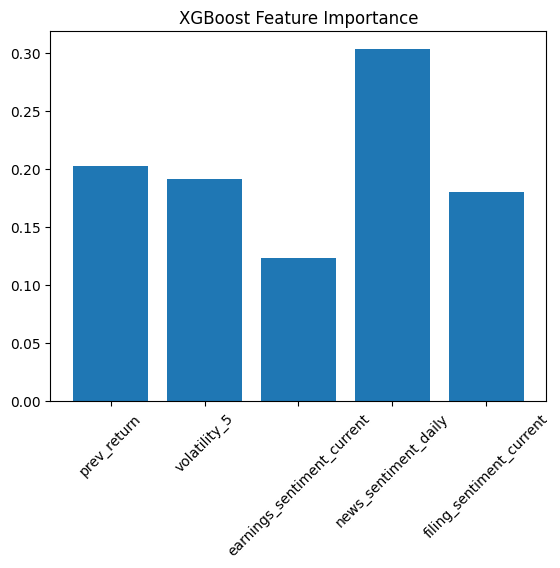

In [ ]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.bar(features, importances)
plt.title("XGBoost Feature Importance")
plt.xticks(rotation=45)
plt.show()

The XGBoost model did not outperform the Random Forest model in terms of RMSE, indicating slightly higher prediction error in magnitude. However, it achieved a significantly higher directional accuracy of 61.2%, compared to approximately 50% for previous models. This suggests that the multimodal feature set, when combined with nonlinear models, is more effective at predicting the direction of stock price movements rather than precise return values. In financial applications, directional accuracy is often more relevant than exact prediction, highlighting the practical value of the proposed approach.

✔ Linear model → fails
✔ Random Forest → improves
✔ XGBoost → improves direction significantly

# LSTM

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/tsla_multimodal_2022.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df.head()

,date,open,high,low,close,volume,return_1d,prev_return,volatility_5,target_next_day_return,earnings_sentiment_current,news_sentiment_daily,filing_sentiment_current
0,2022-01-03,382.583344,400.356659,378.679993,399.926666,103931400,NaN,NaN,NaN,-0.041833,0.0,-0.88,0.942373
1,2022-01-04,396.516663,402.666656,374.350006,383.196655,100248300,-0.041833,NaN,NaN,-0.053471,0.0,0.00,0.942373
2,2022-01-05,382.216675,390.113342,360.336670,362.706665,80119800,-0.053471,-0.041833,NaN,-0.021523,0.0,0.00,0.942373
3,2022-01-06,359.000000,362.666656,340.166656,354.899994,90336600,-0.021523,-0.053471,NaN,-0.035447,0.0,0.00,0.942373
4,2022-01-07,360.123322,360.309998,336.666656,342.320007,84164700,-0.035447,-0.021523,NaN,0.030342,0.0,0.00,0.942373


 Keep only the columns we need

In [ ]:
features = [
    "prev_return",
    "volatility_5",
    "earnings_sentiment_current",
    "news_sentiment_daily",
    "filing_sentiment_current"
]

target = "target_next_day_return"

df_lstm = df[["date"] + features + [target]].dropna().reset_index(drop=True)

print("Rows for LSTM:", len(df_lstm))
df_lstm.head()

Rows for LSTM: 245


,date,prev_return,volatility_5,earnings_sentiment_current,news_sentiment_daily,filing_sentiment_current,target_next_day_return
0,2022-01-10,-0.035447,0.032696,0.0,0.00,0.942373,0.005935
1,2022-01-11,0.030342,0.033297,0.0,0.00,0.942373,0.039290
2,2022-01-12,0.005935,0.032211,0.0,0.00,0.942373,-0.067491
3,2022-01-13,0.039290,0.045170,0.0,-0.94,0.942373,0.017498
4,2022-01-14,-0.067491,0.042515,0.0,-0.83,0.942373,-0.018197


Scale the data correctly

In [ ]:
from sklearn.preprocessing import StandardScaler

# Train/test split by time
split_idx = int(len(df_lstm) * 0.8)

train_df = df_lstm.iloc[:split_idx].copy()
test_df = df_lstm.iloc[split_idx:].copy()

X_train_raw = train_df[features].values
X_test_raw = test_df[features].values

y_train_raw = train_df[[target]].values
y_test_raw = test_df[[target]].values

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_test_scaled = scaler_X.transform(X_test_raw)

y_train_scaled = scaler_y.fit_transform(y_train_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

print("Train shape:", X_train_scaled.shape, y_train_scaled.shape)
print("Test shape:", X_test_scaled.shape, y_test_scaled.shape)

Train shape: (196, 5) (196, 1)
Test shape: (49, 5) (49, 1)


Convert daily data into sequences

In [ ]:
SEQ_LEN = 5

def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train_scaled, SEQ_LEN)
X_test_seq, y_test_seq = make_sequences(X_test_scaled, y_test_scaled, SEQ_LEN)

print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)
print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)

X_train_seq: (191, 5, 5)
y_train_seq: (191, 1)
X_test_seq: (44, 5, 5)
y_test_seq: (44, 1)


 Build the simple LSTM model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

np.random.seed(42)
tf.random.set_seed(42)

model = Sequential([
    LSTM(32, input_shape=(SEQ_LEN, len(features))),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

A simple Long Short-Term Memory (LSTM) network was implemented to model temporal dependencies in the multimodal dataset. The model consists of a single LSTM layer with 32 hidden units, followed by a dropout layer for regularization, and a dense output layer for regression. The total number of trainable parameters is 4,897, making the model relatively lightweight and suitable for the limited dataset size. The LSTM processes sequences of past observations to capture short-term temporal patterns in both market and sentiment features.

Train the model

In [ ]:
history = model.fit(
    X_train_seq,
    y_train_seq,
    epochs=30,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 1.1010 - val_loss: 0.7285
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1040 - val_loss: 0.7655
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0836 - val_loss: 0.7864
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0652 - val_loss: 0.8013
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0521 - val_loss: 0.8150
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0733 - val_loss: 0.8299
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0626 - val_loss: 0.8501
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0456 - val_loss: 0.8559
Epoch 9/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0360 - val_loss: 0.8635
Epoch 10/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0220 - val_loss: 0.8665
Epoch 11/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0449 - val_loss: 0.8660
Epoch 12/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0275 - val_l

Predict and evaluate

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict
pred_scaled = model.predict(X_test_seq)

# Convert back to original scale
pred = scaler_y.inverse_transform(pred_scaled).flatten()
y_true = scaler_y.inverse_transform(y_test_seq).flatten()

# Metrics
rmse = np.sqrt(mean_squared_error(y_true, pred))
mae = mean_absolute_error(y_true, pred)
dir_acc = np.mean((y_true > 0) == (pred > 0))

print("LSTM Results:")
print("RMSE:", rmse)
print("MAE:", mae)
print("Directional Accuracy:", dir_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
LSTM Results:
RMSE: 0.05477908940806429
MAE: 0.04409864066071087
Directional Accuracy: 0.36363636363636365


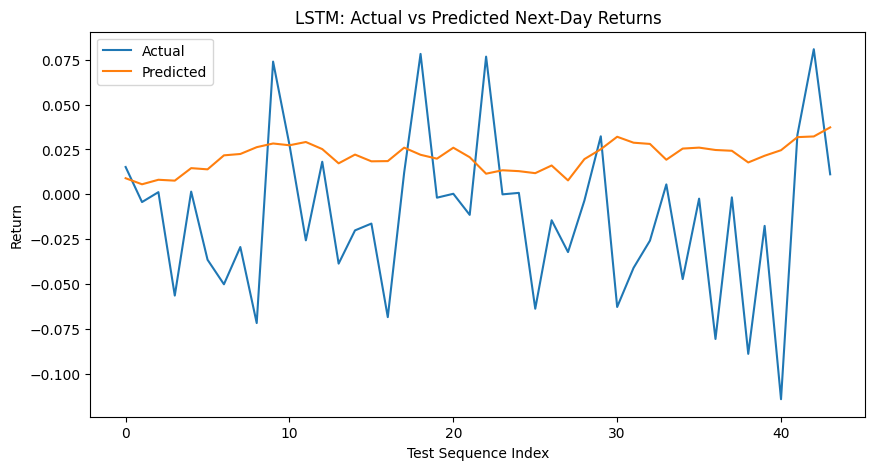

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_true, label="Actual")
plt.plot(pred, label="Predicted")
plt.title("LSTM: Actual vs Predicted Next-Day Returns")
plt.xlabel("Test Sequence Index")
plt.ylabel("Return")
plt.legend()
plt.show()

“Tree-based nonlinear models remained competitive or stronger than sequence-based deep learning under the limited 2022 multimodal sample, while the LSTM served as a proof-of-concept deep fusion model.”


The LSTM model underperformed compared to tree-based models, achieving higher RMSE and significantly lower directional accuracy (36.3%). This is likely due to the limited size of the 2022 dataset and the sparse nature of sentiment signals. Deep learning models such as LSTM typically require larger datasets to effectively learn temporal dependencies, whereas tree-based models like XGBoost are better suited for smaller tabular datasets. These findings suggest that, in this setting, nonlinear tree-based methods are more effective than sequence-based deep learning approaches.

⸻


In [ ]:
tsla_full.to_csv("/content/tsla_multimodal_2022.csv", index=False)

In [ ]:
df = pd.read_csv("/content/tsla_multimodal_2022.csv")

In [ ]:
import os
print(os.listdir("/content"))

['.config', 'tsla_multimodal_2022.csv', '10-Q Sentiment.csv', 'tesla_earnings_sentiment.csv', '10-k Sentiment.csv', 'Tesla_sentiment_2022.csv', 'sample_data']


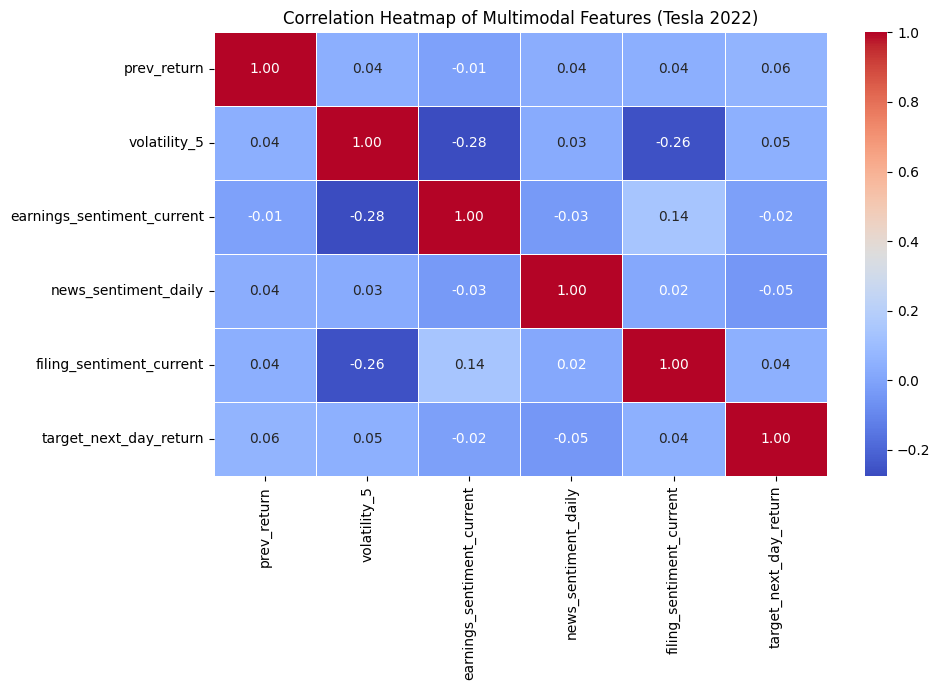

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    "prev_return",
    "volatility_5",
    "earnings_sentiment_current",
    "news_sentiment_daily",
    "filing_sentiment_current",
    "target_next_day_return"
]

corr = df[cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Multimodal Features (Tesla 2022)")
plt.tight_layout()
plt.show()